### Data:

Due to kernel/network issues, channel geometries for test and training data were manually pulled from USGS and saved to this repo in VSCode. From there, I used the following code with different ID sets to find bed slope, reach distance, and time from initial (minimum time of training set). The plain/cleaned data saved from USGS is listed as 'USGS-########.csv', while the fixed dataframes are saved under station numbers. Lower numbered stations are set furthur upstream. 

In [3]:
import pandas as pd
import datetime as dt
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
import pynhd as nhd
from pynhd import NLDI
import geopandas as gpd
from dataretrieval import nwis

In [ ]:
upstream_id = "09315000"
downstream_id = "09328920"

## Slope field to estimate using NLDI

In [46]:
#nldi will work upstream, so using downstream for this code block
nldi = NLDI()

basin = nldi.get_basins(downstream_id)
flowlines = nldi.navigate_byid(
        fsource="nwissite",
        fid=f"USGS-{downstream_id}",
        navigation='upstreamMain',
        source='flowlines',
        distance=1000,
        trim_start=True
    )

vaa = nhd.nhdplus_vaa("input_data/nhdplus_vaa.parquet")
flowlines["comid"] = pd.to_numeric(flowlines.nhdplus_comid)
slope = gpd.GeoDataFrame(
    pd.merge(flowlines, vaa[["comid", "slope"]], left_on="comid", right_on="comid"),
    crs=flowlines.crs,
)
slope[slope.slope < 0] = np.nan

In [53]:
st_all = nldi.navigate_byid(
    fsource="nwissite",
    fid=f"USGS-{downstream_id}",
    navigation="upstreamTributaries",
    source="nwissite",
    distance=1000,
)
st_active = st_all[st_all['identifier'].isin(['USGS-09315000'])]

/var/folders/gt/m7_lxk5j1mn90fqjrx8y57300000gn/T/ipykernel_80002/648141033.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="best")


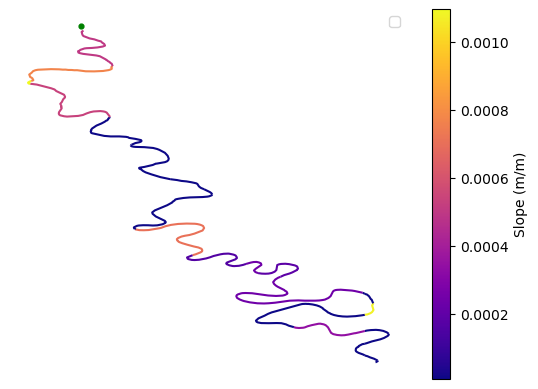

In [ ]:
#Plot the slope attribute for the flowlines of the tributaries of the station

ax = slope.head(25).plot(
    column="slope",
    cmap="plasma",
    legend=True,
    legend_kwds={"label": "Slope (m/m)"},
)

st_active.plot(
    ax=ax,
    marker="o",
    markersize=12,
    zorder=5,
    color="green",
)

ax.legend(loc="best")
ax.set_aspect("auto")
ax.set_axis_off()
ax.figure.set_dpi(100)

ax.set_axis_off()

In [ ]:
#Get lengths 
slope_field = slope.head(26)
slope_field = gpd.GeoDataFrame(slope_field,geometry='geometry', crs="EPSG:4326")
slope_field = slope_field.to_crs("EPSG:32612")
slope_field["length_m"] = slope_field.length

In [ ]:
#double check and save 
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)
slope_field['slope'].iloc[25:51]
slopecsv = pd.DataFrame()
slopecsv['slope'] = slope_field['slope']
slopecsv['length_m'] = slope_field['length_m']
slopecsv.to_csv('slopes.csv')

In [ ]:
#Manually compiled all of the slope fields into one data set, then saved to VsCode. 
#The actual distances from upstream are cumulative summed here and stored
S_0 = pd.read_csv('/PINN_Project/slope_field.csv')
S_0['length (m)'] = (S_0['length_m'].cumsum())
S_0.to_csv('slope_field.csv')

Making the test datasets, with x,t,and Q for comparison, repeated for all USGS stations:

In [ ]:
data= nwis.get_dv(sites='09328920', parameterCd='00060', 
                    start='2018-01-01', end='2019-12-31')

In [45]:
initial = "2016-01-07 14:05:00"
initial = pd.Timestamp(initial, tz="UTC")
test = data[0]
#test.head()
test['t (days)'] = (test.index- initial).total_seconds() / 86400
test = test.reset_index()
test['x (m)'] = 427.359347 * 1000

saving = pd.DataFrame()
saving['x (m)'] = test['x (m)']
saving['t (days)'] = test['t (days)']
saving['Q (cms)'] = test['00060_Mean'] / 35.31467
saving.to_csv('test4.csv')